In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression

In [1]:
# Importar el dataset desde sklearn
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Cargar el dataset
housing = fetch_california_housing(as_frame=True)

# Lo convertimos a dataframe y mostramos
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Calcular la matriz de correlación
corr_matrix = df.corr()

corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


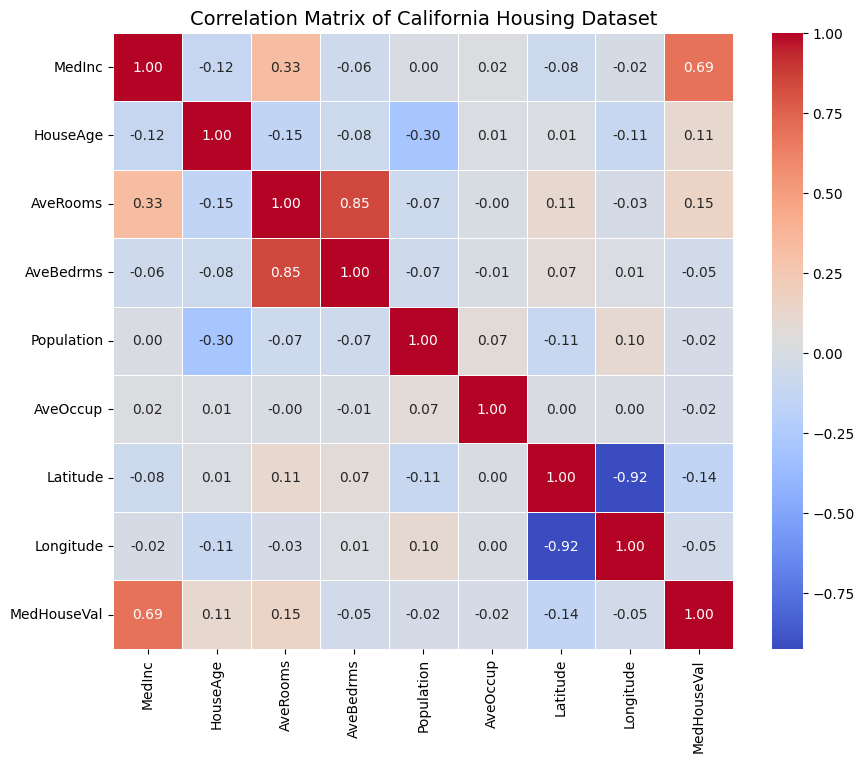

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)

plt.title("Correlation Matrix of California Housing Dataset", fontsize=14)
plt.show()


### Separar variable objetivo y features

Variable objetivo: median_house_value

In [13]:
# Separar variable objetivo y features
target = 'MedHouseVal'

X = df.drop(columns=[target])
y = df[target]

In [14]:
from sklearn.feature_selection import mutual_info_regression

# Mutual Information
mi_scores = mutual_info_regression(X, y, random_state=42)

# Convertir a Serie con nombres
mi_scores = pd.Series(mi_scores, index=X.columns)

# Ordenar
mi_scores = mi_scores.sort_values(ascending=False)

mi_scores

,0
Longitude,0.400147
MedInc,0.387097
Latitude,0.370763
AveRooms,0.102874
AveOccup,0.072716
HouseAge,0.033368
AveBedrms,0.024149
Population,0.020878


In [15]:
print("🔎 Variables ordenadas por importancia (Mutual Information):\n")
print(mi_scores)

🔎 Variables ordenadas por importancia (Mutual Information):

Longitude     0.400147
MedInc        0.387097
Latitude      0.370763
AveRooms      0.102874
AveOccup      0.072716
HouseAge      0.033368
AveBedrms     0.024149
Population    0.020878
dtype: float64


# Conclusión

El análisis del California Housing Dataset permitió identificar qué variables aportan mayor información para predecir la variable objetivo MedHouseVal. Se utilizaron dos enfoques: la matriz de correlación y la métrica Mutual Information (MI), ambas aplicadas a las variables numéricas del dataset.

### Hallazgos principales

1. Las variables con mayor aportación predictiva según MI fueron:

* Longitude (0.4001)

* MedInc — Median Income (0.3871)

* Latitude (0.3707)

Estas tres variables contienen la mayor proporción de información relevante para explicar la variabilidad en el valor de las casas (MedHouseVal).

2. La correlación confirmó la importancia de MedInc, mostrando un coeficiente moderadamente fuerte (≈ 0.68), lo que indica que a mayor ingreso medio de los residentes, mayor tiende a ser el valor de la vivienda.

3. Latitude y Longitude también mostraron relación significativa, reflejando la influencia geográfica del mercado inmobiliario en California (zonas costeras ⟶ valores más altos).

4. Variables estructurales como AveRooms, AveOccup y HouseAge mostraron contribución menor, aunque no despreciable, sugiriendo que las características internas del hogar influyen, pero no tanto como la ubicación o el nivel socioeconómico.

5. Population y AveBedrms fueron las menos informativas, lo que significa que aportan poco valor para mejorar la predicción del precio de la vivienda.

El análisis conjunto de correlación y Mutual Information revela que los factores socioeconómicos (MedInc) y geográficos (Latitude, Longitude) son los predictores más importantes del valor de las viviendas en California.
Esto tiene sentido para el comportamiento real del mercado: las zonas con mayores ingresos y mejor ubicación tienden a concentrar las propiedades de mayor valor.